## Segunda etapa

Em segunda_etapa.ipynb, utilizaremos dos registros que coletamos em primeira_etapa.ipynb e faremos nossa primeira filtragem: o país cujo a exsicata foi registrada. Essa etapa é necessária para o foco em uma região de estudo específica.

Adotaremos uma prática de criar sempre um novo campo no banco de dados quando realizarmos uma filtragem, colocando os registros filtrados nesse novo campo, a fim de preservar os campos originais. Por convenção, o nome desse campo sempre será campo-original_att. Nesse caso, o nome será country_att, pois o nome do campo original é country.

Caso não deseje realizar essa filtragem, siga utilizando o campo country ao invés de country_att nas próximas filtragens.

In [3]:
from bibliotecas import *

specieslink, db_config = configurar()

In [6]:
conn = mysql_conn.connect(**db_config)
cursor = conn.cursor()

coluna = "country"
table = "registros_biodiversidade"

sql = f"""SELECT {coluna} FROM {table} WHERE {coluna} IS NOT NULL GROUP BY {coluna}"""

cursor.execute(sql)
resultados = cursor.fetchall()

for resultado in resultados:
    print(resultado[0])

cursor.close()
conn.close()  

Brasil
Argentina
México
Estados Unidos
Paraguai
Federative Republic of Brazil
BR
Brazil
Alemanha
Malásia
MG
E.U.A.
Chili
Brésil
Equateur
Paraguay
Chile
Bolivie
Venezuela
[Uruguay]
Ecuador
Peru
?
Bolivia
Colombia
Suécia
Indisponível
Equador
França
Suíça
U.S.A.
Canadá
Germany
France
El Salvador
Portugal
Austrália
Honduras
Japan
Finland
Áustria
Norway
UK
China
Morocco
Índia
Uruguai
Sri Lanka
Philippines
Solomon Islands
Unknown
Italy
Poland
Panamá
Bulgária
Cuba
New Zealand
Samoa
New Caledonia
Taiwan
Inglaterra
Polinésia Francesa
Virginia
Uruguay
Polônia
Guiana
Suriname
Guiana Francesa
Dinamarca (Zealand)
Trinidad and Tobago
Guyana
Rio de Janeiro
Bosnia and Herzegowina
Dominican Republic
Papua New Guinea
Fiji
Spain
Indeterminado
Noruega
Guiana Inglesa
Estados Unidos da América
Acapulco
Japão
French Guiana
Colombie
[Colombie]
Pérou
Moçambique
[Chili]
de Surinam
[venezuela]
Argentine
[Brésil]
Nova Granata
Ile de Pâques
Guyane britannique
Amérique équatoriale
[Paraguay]
[Equateur]
[Pérou]
[Bol

Observe os nomes que se adequam ao país que você precisa. No nosso caso, através de intervenção humana, podemos ver que os registros de país registrados como "Brasil, Brazil, Brésil, [Brésil], BR, Federative Republic of Brazil, Rio de Janeiro" serão os que utilizaremos.

Note que você deve informar os campos sem espaços no meio, então Brasil,Brazil,Brésil...

In [9]:
def filtragem(campo_input, update_input, filters_input, table):
    if not campo_input:
        print("por favor insira um campo")
        return
    
    conn = mysql_conn.connect(**db_config)
    cursor = conn.cursor()

    try:
        sql = f"ALTER TABLE {table} ADD COLUMN {campo_input} TEXT"

        cursor.execute(sql)
        conn.commit()

        print(f"campo '{campo_input}' criado com sucesso na tabela '{table}'")

        cursor.close()
        conn.close()  
    except Exception as e:
        print(f"campo '{campo_input}' já existe ou erro ao criar: {e}")
        
    filters = {}
    if '=' not in filters_input:
        print("filtro mal formatado: use campo=valor1,valor2,...")
        return

    key, value = filters_input.split('=', 1)
    values = [v.strip() for v in value.split(',') if v.strip()]
    filters[key.strip()] = values

    update_values = {}
    for item in update_input.split():
        if '=' not in item: # não está formatado
            print(f"valor de atualização mal formatado: {item} - use chave=valor")
            return
        else:
            key, value = item.split('=', 1)
            update_values[key.strip()] = value.strip()

    filter_field, filter_values = next(iter(filters.items()))
    update_field, update_value = next(iter(update_values.items()))
    for valor in filter_values:
        specieslink.update_records(filters={filter_field: valor}, update_values={update_field: update_value}, db_config=db_config, table=table)

In [10]:
campo_input = input("informe o nome que voce deseja que o novo campo tenha (não crie o campo manualmente quando executando pelo pipeline!)").strip()
update_input = input("informe o campo e o valor novo a atualizar (formato chave=valor, separados por espaço): ").strip()
filters_input = input("informe o campo e o valor antigo a ser atualizado (formato chave=valor, separados por espaço): ").strip()
table = "registros_biodiversidade"
print(f"executando specieslink.update_records(filters={filters_input}, update_values={update_input}, table={table})...\n")

filtragem(campo_input=campo_input, update_input=update_input, filters_input=filters_input, table=table)

executando specieslink.update_records(filters=country=Brasil,Brazil,Brésil,[Brésil],BR,Federative Republic of Brazil,Rio de Janeiro, update_values=country_att=Brasil, table=registros_biodiversidade)...

campo 'country_att' criado com sucesso na tabela 'registros_biodiversidade'
conexão bem-sucedida
query gerada para UPDATE: 
                UPDATE teste_pipeline.registros_biodiversidade
                SET country_att = %s
                WHERE country = %s
            
valores para UPDATE: ['Brasil', 'Brasil']
18824 registro(s) atualizado(s).
conexão encerrada
conexão bem-sucedida
query gerada para UPDATE: 
                UPDATE teste_pipeline.registros_biodiversidade
                SET country_att = %s
                WHERE country = %s
            
valores para UPDATE: ['Brasil', 'Brazil']
3192 registro(s) atualizado(s).
conexão encerrada
conexão bem-sucedida
query gerada para UPDATE: 
                UPDATE teste_pipeline.registros_biodiversidade
                SET country_att =

In [11]:
conn = mysql_conn.connect(**db_config)
cursor = conn.cursor()

sql = """
SELECT
    COUNT(*) AS total_registros,
    SUM(country_att IS NOT NULL) AS registros_utilizados
FROM registros_biodiversidade
"""

cursor.execute(sql)
total_registros, registros_utilizados = cursor.fetchone()

cursor.close()
conn.close()

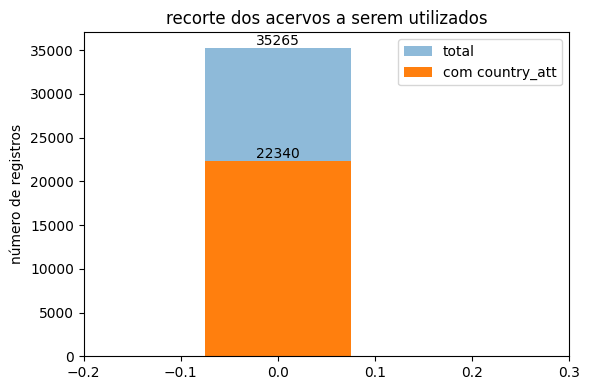

In [12]:
plt.figure(figsize=(6, 4))

x = [0]

plt.bar(
    x,
    [total_registros],
    alpha=0.5,
    width=0.15,
    label='total'
)

plt.bar(
    x,
    [registros_utilizados],
    width=0.15,
    label='com country_att'
)

plt.xlim(-0.2, 0.3)
plt.ylabel('número de registros')
plt.title('recorte dos acervos a serem utilizados')
plt.legend()

plt.text(0, total_registros, str(total_registros), ha='center', va='bottom')
plt.text(0, registros_utilizados, str(registros_utilizados), ha='center', va='bottom')

plt.tight_layout()
plt.show()